# Kalman Filter — Teamsterkte op basis van Goals


**Model:**
```
home_goals = δ + α_home - γ_away + v   (meetruis v ~ N(0, σ_v²))
away_goals =     α_away - γ_home + v
α_i,k = φ · α_i,k-1 + w               (procesruis w ~ N(0, σ_w²))
```

**Hyperparameters conform literatuur:**
- φ ≈ 0.98-0.99 (persistentie teamsterkte)
- σ_w klein (sterkte verandert langzaam)
- σ_v groter (goals hebben veel ruis)
- δ = thuisvoordeel

In [1]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Laad data — gebruik training_data.csv (alle seizoenen, ook zonder xG)
df = pd.read_csv('training_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Alleen gespeelde wedstrijden met goals
df_goals = df[
    df['status'].isin(['Ended','finished']) &
    df['home_goals'].notna() &
    df['away_goals'].notna()
].copy().reset_index(drop=True)

print(f'Totaal wedstrijden:    {len(df)}')
print(f'Met goals data:        {len(df_goals)}')
print(f'Seizoenen:             {sorted(df_goals["season"].unique())}')
print(f'Gemiddelde home goals: {df_goals["home_goals"].mean():.3f}')
print(f'Gemiddelde away goals: {df_goals["away_goals"].mean():.3f}')

Totaal wedstrijden:    2661
Met goals data:        2581
Seizoenen:             ['2019-2020', '2020-2021', '2021-2022', '2022-2023', '2024-2025', '2025-2026', '23/24']
Gemiddelde home goals: 1.548
Gemiddelde away goals: 1.318


## Stap 2 — Hyperparameters

Conform de literatuur:
- **φ (PHI)**: dicht bij 1 — teamsterkte verandert langzaam binnen een seizoen
- **σ_w (SIGMA_W)**: kleine procesruis — sterkte evolueert stabiel
- **σ_v (SIGMA_V)**: meetruis — goals hebben meer ruis dan xG
- **δ (DELTA)**: thuisvoordeel — gemiddeld ~0.5 goals meer thuis in de Premier League

In [2]:
# Hyperparameters conform Manner (2015) en Leushuis (2017)
PHI     = 0.98   # AR(1) persistentie
SIGMA_W = 0.10   # Procesruis (iets hoger dan xG versie vanwege meer goals ruis)
SIGMA_V = 1.20   # Meetruis (goals hebben meer ruis dan xG)
DELTA   = 0.2   # Thuisvoordeel in goals (Premier League gemiddelde)

# Initiële state: alle teams starten neutraal
INIT_MEAN = 0.0
INIT_VAR  = 1.0

print(f'Hyperparameters:')
print(f'  PHI     = {PHI}   (persistentie teamsterkte)')
print(f'  SIGMA_W = {SIGMA_W}  (procesruis)')
print(f'  SIGMA_V = {SIGMA_V}  (meetruis goals)')
print(f'  DELTA   = {DELTA}  (thuisvoordeel in goals)')
print(f'\nWerkelijk gemiddeld thuisvoordeel in data: {df_goals["home_goals"].mean() - df_goals["away_goals"].mean():.3f} goals')

Hyperparameters:
  PHI     = 0.98   (persistentie teamsterkte)
  SIGMA_W = 0.1  (procesruis)
  SIGMA_V = 1.2  (meetruis goals)
  DELTA   = 0.2  (thuisvoordeel in goals)

Werkelijk gemiddeld thuisvoordeel in data: 0.230 goals


## Stap 3 — Kalman Filter

Per wedstrijd drie fases:
1. **Predict**: schat teamsterkte op basis van vorige wedstrijd
2. **Observeer**: bereken innovatie (werkelijk - voorspeld)
3. **Update**: pas teamsterkte aan via Kalman gain

In [3]:
teams = sorted(set(df_goals['home_team']) | set(df_goals['away_team']))
print(f'Aantal teams: {len(teams)}')

# Initialiseer state
alpha     = {t: INIT_MEAN for t in teams}  # aanvalskracht
gamma     = {t: INIT_MEAN for t in teams}  # verdedigingskracht
var_alpha = {t: INIT_VAR  for t in teams}  # onzekerheid aanval
var_gamma = {t: INIT_VAR  for t in teams}  # onzekerheid verdediging

results = []

for _, row in df_goals.iterrows():
    h = row['home_team']
    a = row['away_team']

    # ── 1. PREDICT ──────────────────────────────────────────────────────────
    # State evolueert via AR(1): x_k|k-1 = φ * x_k-1|k-1
    a_h = PHI * alpha[h];    a_a = PHI * alpha[a]
    g_h = PHI * gamma[h];    g_a = PHI * gamma[a]

    # Predicted variantie: Σ_k|k-1 = φ² * Σ_k-1|k-1 + σ_w²
    va_h = PHI**2 * var_alpha[h] + SIGMA_W**2
    va_a = PHI**2 * var_alpha[a] + SIGMA_W**2
    vg_h = PHI**2 * var_gamma[h] + SIGMA_W**2
    vg_a = PHI**2 * var_gamma[a] + SIGMA_W**2

    # ── 2. OBSERVATIE ───────────────────────────────────────────────────────
    # Verwachte goals op basis van huidige state
    goals_h_pred = DELTA + a_h - g_a
    goals_a_pred =         a_a - g_h

    # Innovatie: verschil werkelijk vs voorspeld
    e_h = row['home_goals'] - goals_h_pred
    e_a = row['away_goals'] - goals_a_pred

    # Innovatievariantie: S = Σ_alpha + Σ_gamma + σ_v²
    S_h = va_h + vg_a + SIGMA_V**2
    S_a = va_a + vg_h + SIGMA_V**2

    # ── 3. KALMAN GAIN ──────────────────────────────────────────────────────
    # K = Σ_k|k-1 / S  (hoe zwaar weeg je de nieuwe observatie)
    K_alpha_h = va_h / S_h;    K_gamma_a = vg_a / S_h
    K_alpha_a = va_a / S_a;    K_gamma_h = vg_h / S_a

    # ── 4. UPDATE ───────────────────────────────────────────────────────────
    # x_k|k = x_k|k-1 + K * innovatie
    alpha[h] = a_h + K_alpha_h * e_h
    alpha[a] = a_a + K_alpha_a * e_a
    gamma[a] = g_a - K_gamma_a * e_h   # gamma daalt als team meer goals weggeeft
    gamma[h] = g_h - K_gamma_h * e_a

    # Σ_k|k = (1 - K) * Σ_k|k-1
    var_alpha[h] = (1 - K_alpha_h) * va_h
    var_alpha[a] = (1 - K_alpha_a) * va_a
    var_gamma[a] = (1 - K_gamma_a) * vg_a
    var_gamma[h] = (1 - K_gamma_h) * vg_h

    # Sla PRE-match state op (voor de update — geen leakage)
    results.append({
        'match_id':           row['match_id'],
        'timestamp':          row['timestamp'],
        'season':             row['season'],
        'home_team':          h,
        'away_team':          a,
        'home_goals':         row['home_goals'],
        'away_goals':         row['away_goals'],
        # Pre-match Kalman state
        'kalman_alpha_home':  a_h,
        'kalman_gamma_home':  g_h,
        'kalman_alpha_away':  a_a,
        'kalman_gamma_away':  g_a,
        # Afgeleide features
        'kalman_attack_diff':    a_h - a_a,
        'kalman_defense_diff':   g_h - g_a,
        'kalman_goals_pred_home': goals_h_pred,
        'kalman_goals_pred_away': goals_a_pred,
        'kalman_goals_pred_diff': goals_h_pred - goals_a_pred,
    })

kalman_df = pd.DataFrame(results)
print(f'Kalman filter gedraaid op {len(kalman_df)} wedstrijden')
print(f'\nVoorspelde goals gemiddeld:')
print(f'  Home: {kalman_df["kalman_goals_pred_home"].mean():.3f}  (werkelijk: {kalman_df["home_goals"].mean():.3f})')
print(f'  Away: {kalman_df["kalman_goals_pred_away"].mean():.3f}  (werkelijk: {kalman_df["away_goals"].mean():.3f})')
kalman_df[['home_team','away_team','kalman_alpha_home','kalman_gamma_home',
           'kalman_goals_pred_home','kalman_goals_pred_away']].head(10)

Aantal teams: 28
Kalman filter gedraaid op 2581 wedstrijden

Voorspelde goals gemiddeld:
  Home: 1.340  (werkelijk: 1.548)
  Away: 1.140  (werkelijk: 1.318)


,home_team,away_team,kalman_alpha_home,kalman_gamma_home,kalman_goals_pred_home,kalman_goals_pred_away
0,Liverpool,Norwich City,0.0,0.0,0.2,0.0
1,West Ham United,Manchester City,0.0,0.0,0.2,0.0
2,Bournemouth,Sheffield United,0.0,0.0,0.2,0.0
3,Burnley,Southampton,0.0,0.0,0.2,0.0
4,Watford,Brighton & Hove Albion,0.0,0.0,0.2,0.0
5,Crystal Palace,Everton,0.0,0.0,0.2,0.0
6,Tottenham Hotspur,Aston Villa,0.0,0.0,0.2,0.0
7,Leicester City,Wolverhampton,0.0,0.0,0.2,0.0
8,Newcastle United,Arsenal,0.0,0.0,0.2,0.0
9,Manchester United,Chelsea,0.0,0.0,0.2,0.0


## Stap 4 — Visualisatie teamsterktes

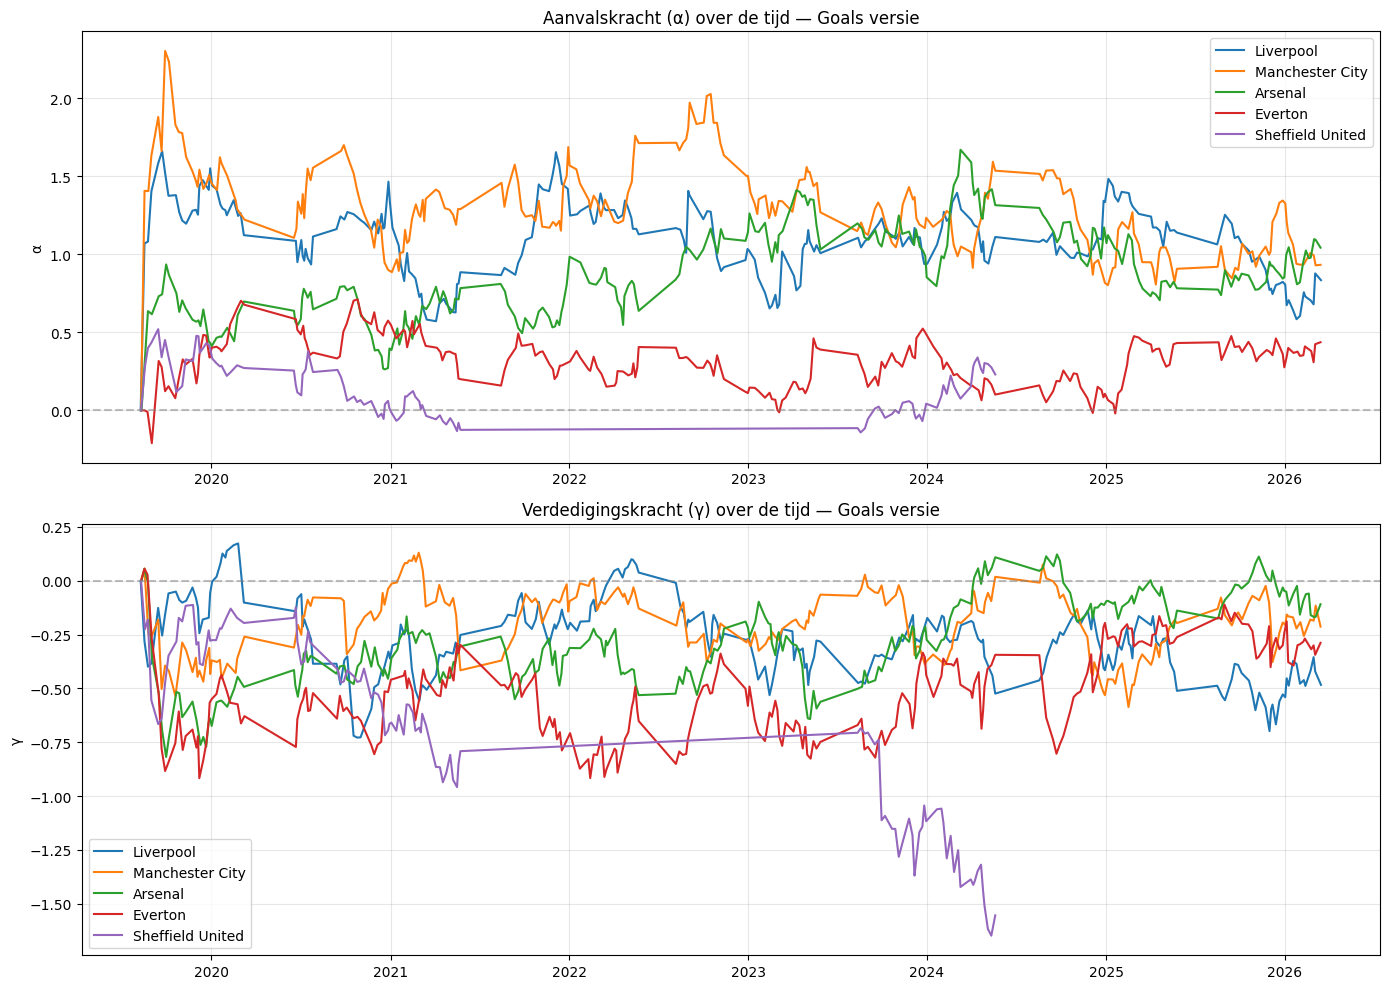

In [4]:
teams_to_plot = ['Liverpool', 'Manchester City', 'Arsenal', 'Everton', 'Sheffield United']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for team in teams_to_plot:
    home = kalman_df[kalman_df['home_team'] == team][['timestamp','kalman_alpha_home']].rename(columns={'kalman_alpha_home':'alpha'})
    away = kalman_df[kalman_df['away_team'] == team][['timestamp','kalman_alpha_away']].rename(columns={'kalman_alpha_away':'alpha'})
    data = pd.concat([home, away]).sort_values('timestamp')
    axes[0].plot(data['timestamp'], data['alpha'], label=team)

axes[0].set_title('Aanvalskracht (α) over de tijd — Goals versie')
axes[0].set_ylabel('α')
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

for team in teams_to_plot:
    home = kalman_df[kalman_df['home_team'] == team][['timestamp','kalman_gamma_home']].rename(columns={'kalman_gamma_home':'gamma'})
    away = kalman_df[kalman_df['away_team'] == team][['timestamp','kalman_gamma_away']].rename(columns={'kalman_gamma_away':'gamma'})
    data = pd.concat([home, away]).sort_values('timestamp')
    axes[1].plot(data['timestamp'], data['gamma'], label=team)

axes[1].set_title('Verdedigingskracht (γ) over de tijd — Goals versie')
axes[1].set_ylabel('γ')
axes[1].legend()
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_goals_teamsterktes.png', dpi=150)
plt.show()

## Stap 5 — Evaluatie

In [6]:
def actual_result(row):
    if row['home_goals'] > row['away_goals']:   return 'H'
    elif row['home_goals'] < row['away_goals']: return 'A'
    else:                                       return 'D'

def predicted_result(row):
    diff = row['kalman_goals_pred_home'] - row['kalman_goals_pred_away']
    if diff > 0.2:    return 'H'
    elif diff < -0.2: return 'A'
    else:             return 'D'

eval_df = kalman_df.copy()
eval_df['actual']    = eval_df.apply(actual_result, axis=1)
eval_df['predicted'] = eval_df.apply(predicted_result, axis=1)

# Sla eerste 100 wedstrijden over (filter warmt op)
eval_df = eval_df.iloc[100:]

acc = accuracy_score(eval_df['actual'], eval_df['predicted'])
f1  = f1_score(eval_df['actual'], eval_df['predicted'], average='macro')

print(f'Accuracy:   {acc:.3f}')
print(f'F1 (macro): {f1:.3f}')
print(f'\nConfusion matrix:')
print(pd.crosstab(eval_df['actual'], eval_df['predicted'], margins=True))

Accuracy:   0.500
F1 (macro): 0.450

Confusion matrix:
predicted    A    D     H   All
actual                         
A          408  170   250   828
D          189  117   272   578
H          175  185   715  1075
All        772  472  1237  2481


## Stap 6 — Opslaan als features voor XGBoost

In [6]:
kalman_features = kalman_df[[
    'match_id',
    'kalman_alpha_home',     'kalman_gamma_home',
    'kalman_alpha_away',     'kalman_gamma_away',
    'kalman_attack_diff',    'kalman_defense_diff',
    'kalman_goals_pred_home','kalman_goals_pred_away',
    'kalman_goals_pred_diff',
]]

df_final = df.merge(kalman_features, on='match_id', how='left')
df_final.to_csv('training_data_with_kalman_goals.csv', index=False)

print(f'Opgeslagen als training_data_with_kalman_goals.csv')
print(f'Wedstrijden met Kalman features: {df_final["kalman_alpha_home"].notna().sum()}')
print(f'Kalman kolommen: {list(kalman_features.columns[1:])}')

Opgeslagen als training_data_with_kalman_goals.csv
Wedstrijden met Kalman features: 2581
Kalman kolommen: ['kalman_alpha_home', 'kalman_gamma_home', 'kalman_alpha_away', 'kalman_gamma_away', 'kalman_attack_diff', 'kalman_defense_diff', 'kalman_goals_pred_home', 'kalman_goals_pred_away', 'kalman_goals_pred_diff']
